# ISA 444 Final Project
## Option 1: Hotel Demand Forecasting

This project forecasts daily room demand for 17 hotel properties using the 'sample_hotels.parquet' dataset.

The forecasting horizon is 28 days. The project compares baseline, statistical, machine learning, neural, and foundation-model forecasting approaches using 5-fold time-series cross-validation.

I'm going to use a workflow like this listed:

1. Prepare and validate the data  
2. Visualize the time series  
3. Set up time-series cross-validation  
4. Fit and compare forecasting models  
5. Evaluate models using ME, MAE, RMSE, and MAPE  
6. Count model wins  
7. Produce final 28-day forecasts  
8. Save CSV outputs and forecast plots

## **Step 1: Upload dataset into colab**

In [1]:
!pip install statsforecast utilsforecast coreforecast
!pip install mlforecast lightgbm -q
!pip install neuralforecast -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from utilsforecast.plotting import plot_series
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS, AutoARIMA
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape, bias
from mlforecast import MLForecast
from lightgbm import LGBMRegressor
from neuralforecast import NeuralForecast
from neuralforecast.auto import AutoNBEATS, AutoNHITS

In [2]:
df_raw = pd.read_parquet('sample_hotels-1.parquet')
df_raw.head()

,unique_id,ds,holiday_flag,target_day,target_month,target_year,location_type,hotel_type,y,otb_1,...,otb_51,otb_52,otb_53,otb_54,otb_55,otb_56,otb_57,otb_58,otb_59,otb_60
1430,hotel_0,2022-01-01,no,Sat,Jan,2022,NonSuburban,Resorts & Destinations,0.975309,0.679012,...,0.197531,0.197531,0.197531,0.185185,0.160494,0.160494,0.160494,0.160494,0.160494,0.160494
1431,hotel_0,2022-01-02,no,Sun,Jan,2022,NonSuburban,Resorts & Destinations,0.493827,0.308642,...,0.074074,0.074074,0.074074,0.074074,0.074074,0.061728,0.061728,0.061728,0.061728,0.049383
1432,hotel_0,2022-01-03,no,Mon,Jan,2022,NonSuburban,Resorts & Destinations,0.456790,0.358025,...,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691
1433,hotel_0,2022-01-04,no,Tue,Jan,2022,NonSuburban,Resorts & Destinations,0.592593,0.419753,...,0.074074,0.074074,0.074074,0.074074,0.061728,0.061728,0.037037,0.037037,0.024691,0.024691
1434,hotel_0,2022-01-05,no,Wed,Jan,2022,NonSuburban,Resorts & Destinations,0.530864,0.407407,...,0.074074,0.074074,0.074074,0.074074,0.074074,0.049383,0.049383,0.024691,0.024691,0.012346


## **Step 2: Inspect the dataset**

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10172 entries, 1430 to 298041
Data columns (total 69 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   unique_id      10172 non-null  object        
 1   ds             10172 non-null  datetime64[us]
 2   holiday_flag   10172 non-null  object        
 3   target_day     10172 non-null  object        
 4   target_month   10172 non-null  object        
 5   target_year    10172 non-null  int32         
 6   location_type  10172 non-null  object        
 7   hotel_type     10172 non-null  object        
 8   y              10172 non-null  float64       
 9   otb_1          10172 non-null  float64       
 10  otb_2          10172 non-null  float64       
 11  otb_3          10172 non-null  float64       
 12  otb_4          10172 non-null  float64       
 13  otb_5          10172 non-null  float64       
 14  otb_6          10172 non-null  float64       
 15  otb_7          10172

In [4]:
df_raw.shape

(10172, 69)

In [5]:
df_raw["unique_id"].nunique()

19

## **Step 3: Create the forecasting dataframe**

In [6]:
df = df_raw.copy()

df["ds"] = pd.to_datetime(df["ds"])

df = df[["unique_id", "ds", "y"]].sort_values(["unique_id", "ds"]).reset_index(drop = True)

df.head()


,unique_id,ds,y
0,hotel_0,2022-01-01,0.975309
1,hotel_0,2022-01-02,0.493827
2,hotel_0,2022-01-03,0.456790
3,hotel_0,2022-01-04,0.592593
4,hotel_0,2022-01-05,0.530864


I need to then validate it

In [7]:
df.groupby("unique_id")["ds"].agg(["min", "max", "count"])

,min,max,count
unique_id,,,
hotel_0,2022-01-01,2023-06-30,546
hotel_105,2022-01-01,2023-06-30,546
hotel_112,2022-01-01,2023-06-30,546
hotel_126,2022-01-01,2023-06-30,546
hotel_133,2022-01-01,2023-06-30,546
hotel_14,2022-01-01,2023-06-30,546
hotel_21,2022-01-01,2023-06-30,546
hotel_28,2022-01-01,2023-06-30,546
hotel_35,2022-01-01,2023-06-30,546


In [8]:
df["y"].describe()

,y
count,10172.000000
mean,0.670112
std,0.304575
min,0.000000
25%,0.459283
50%,0.748708
75%,0.950617
max,1.147541


## **Step 5: Interpreatation**

### Data Prep Notes

The dataset contains daily hotel room demand for 19 hotel properties. The data is already in the required long format for the packages I plan on using.

- unique_id: identifies the hotel property
- ds: date of the observation
- y: daily room demand

The data was sorted by hotel and date so it can be used in the forecasting models.

## **Step 6: Visualization**

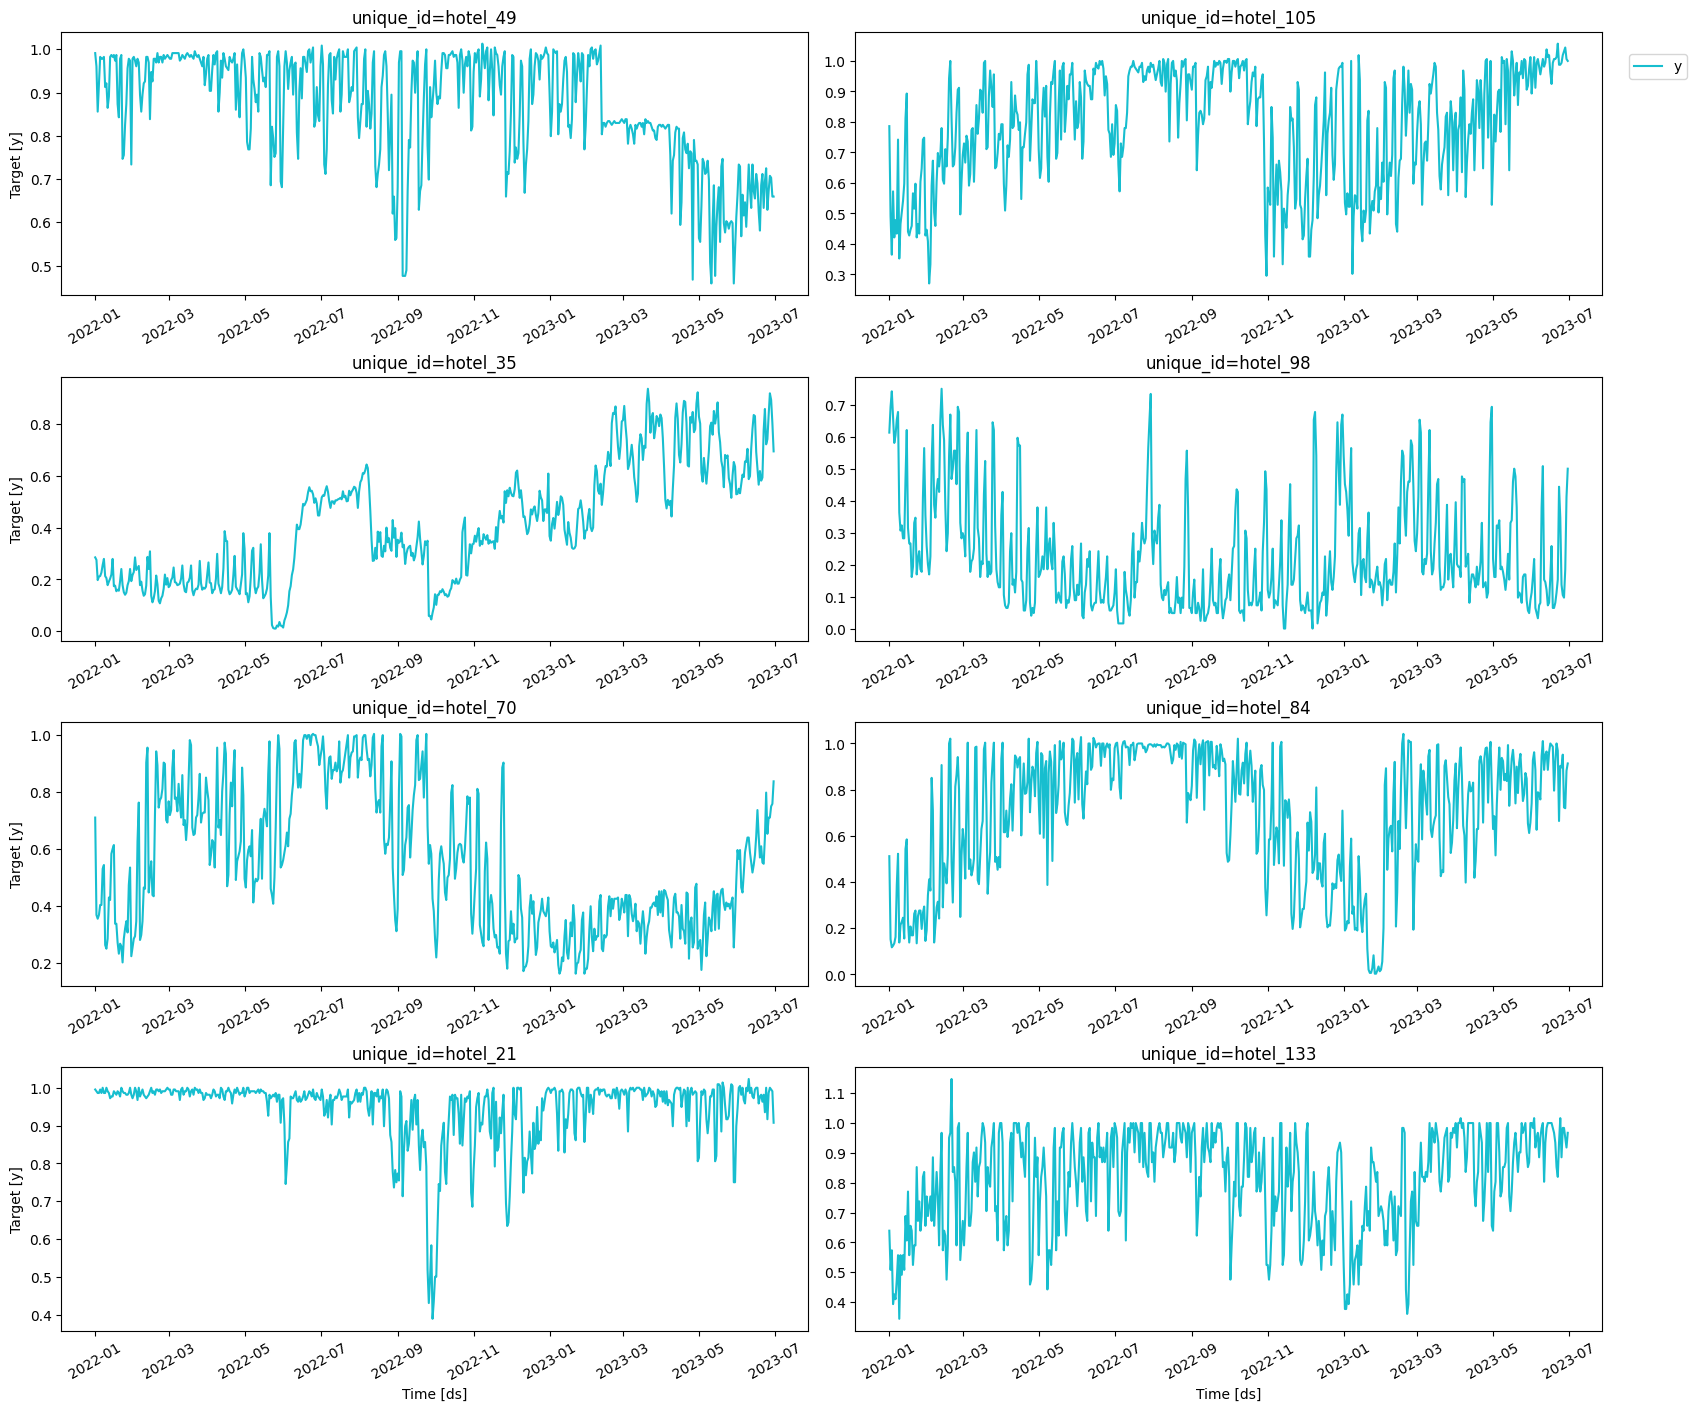

In [9]:
plot_series(df)

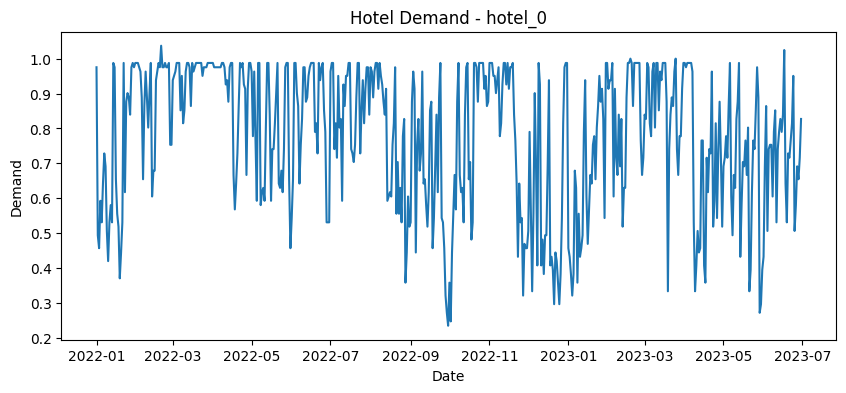

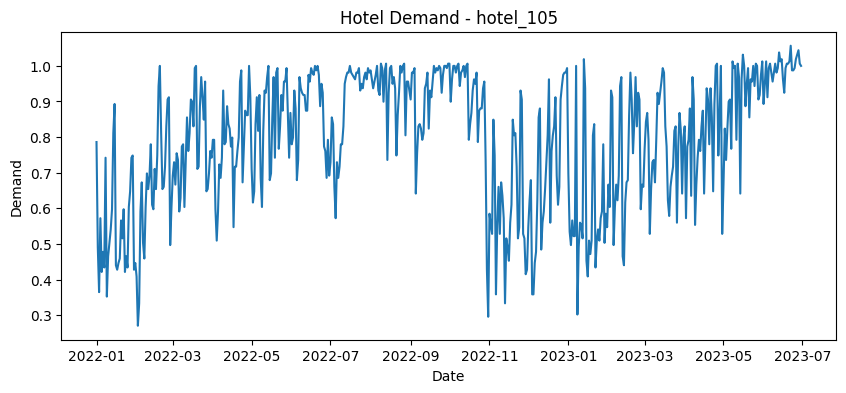

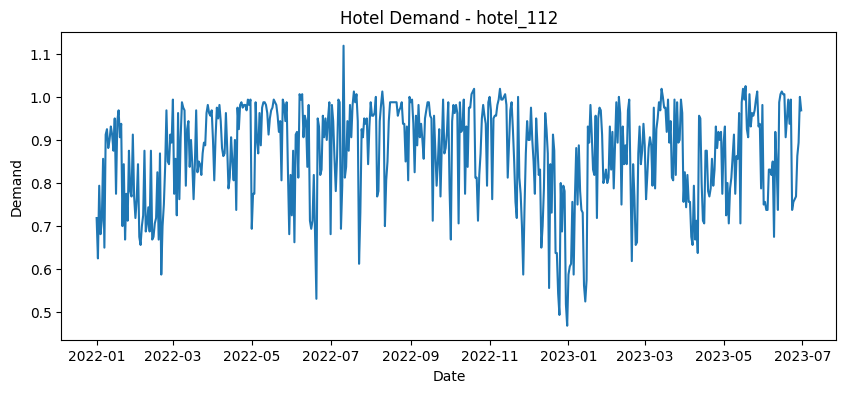

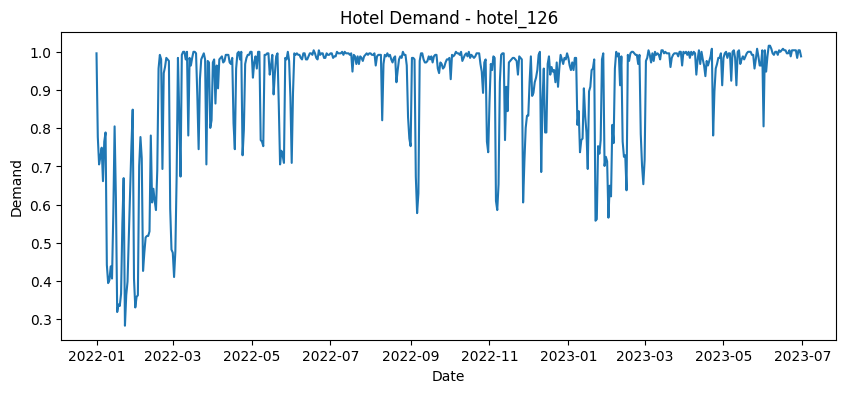

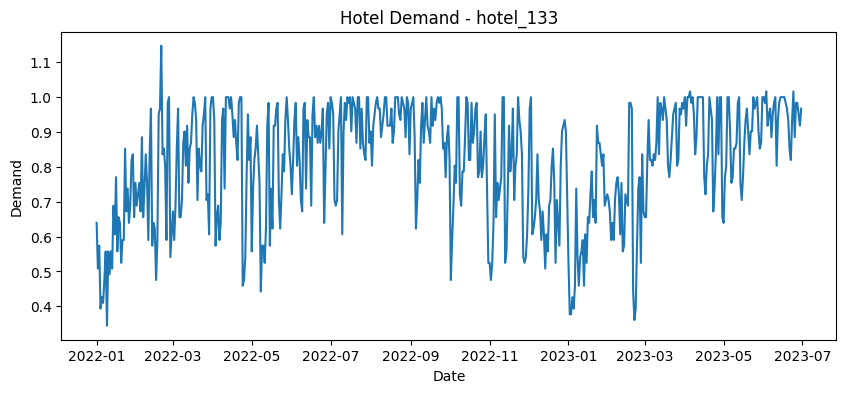

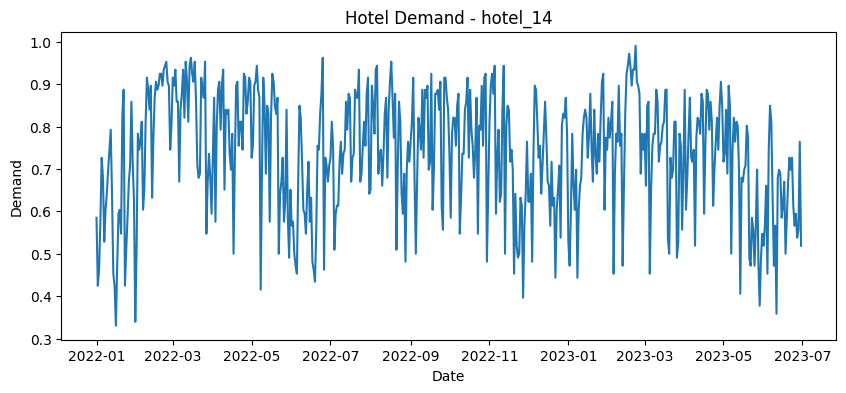

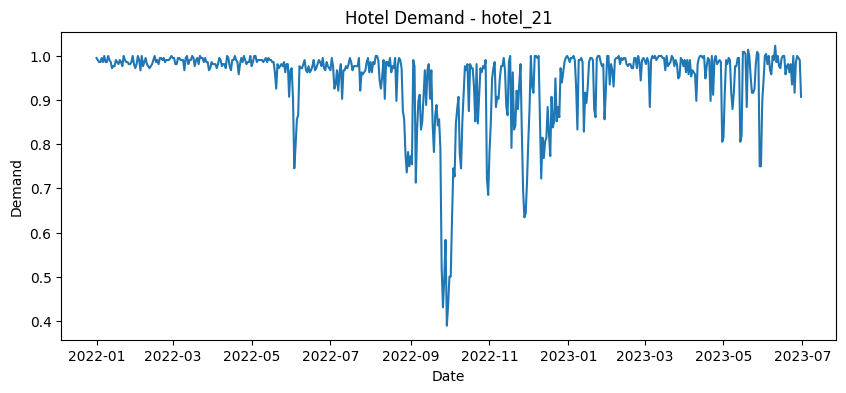

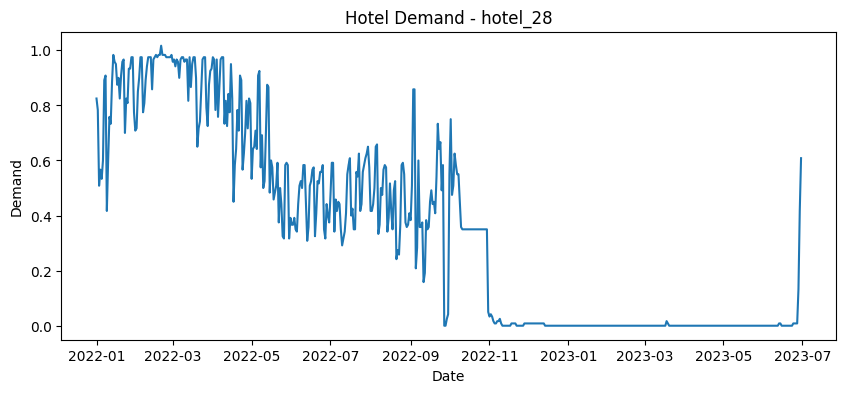

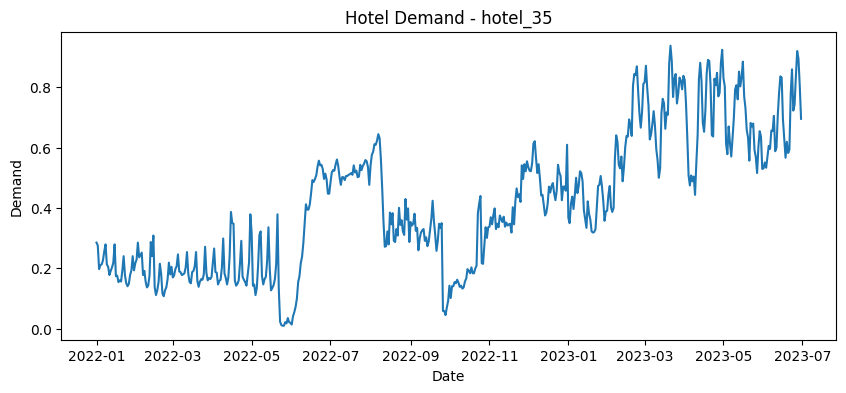

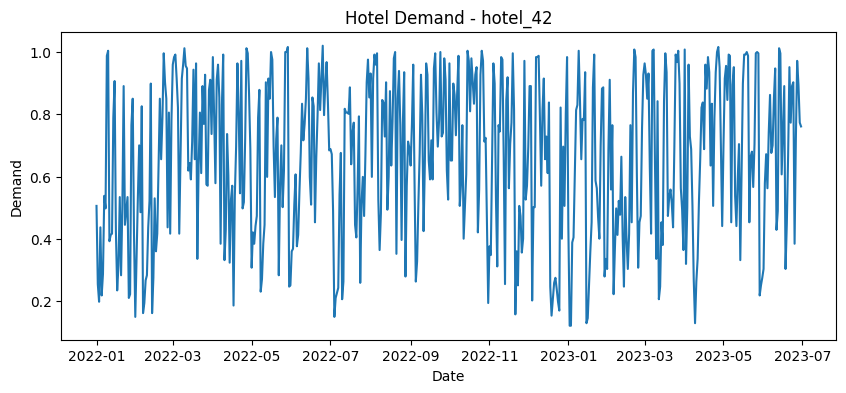

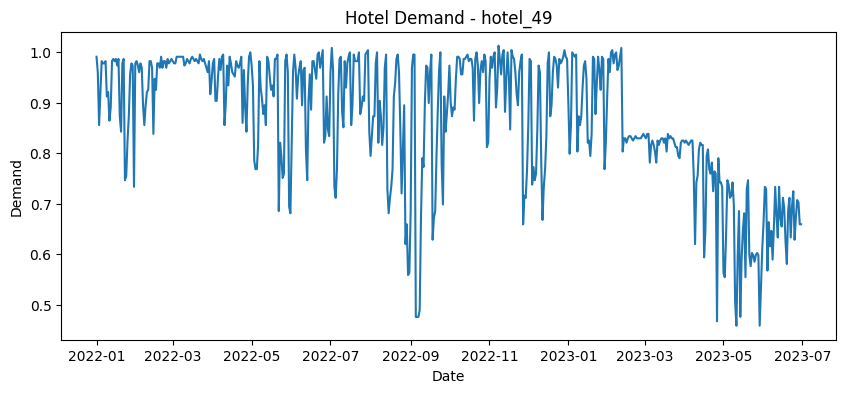

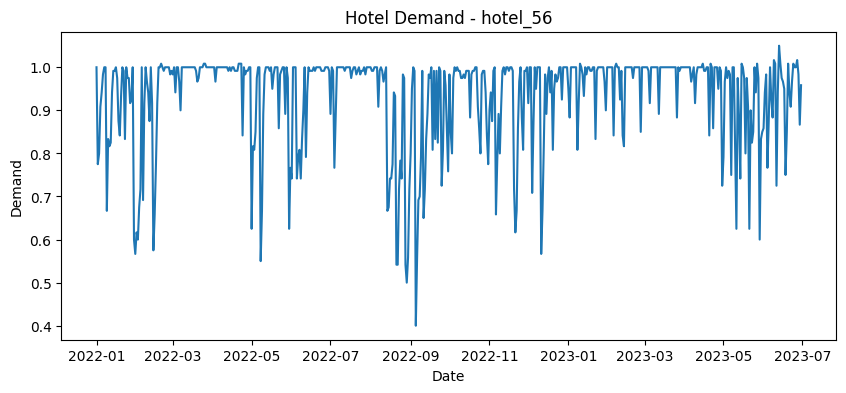

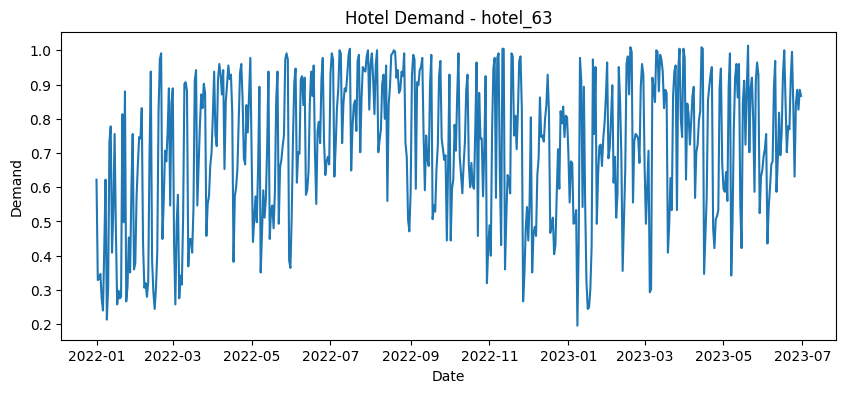

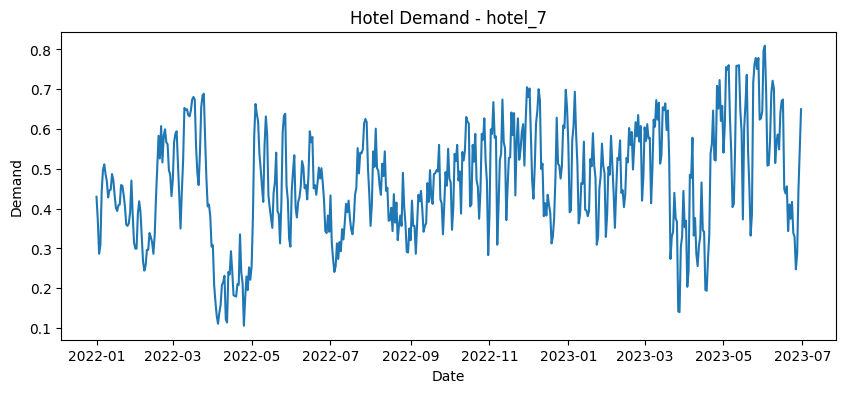

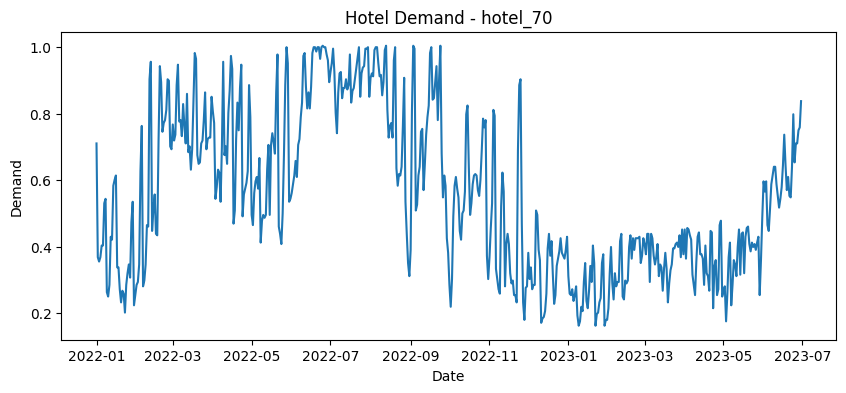

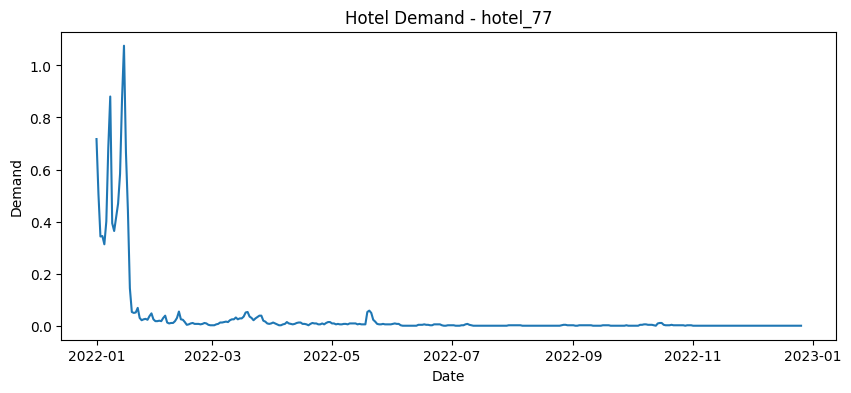

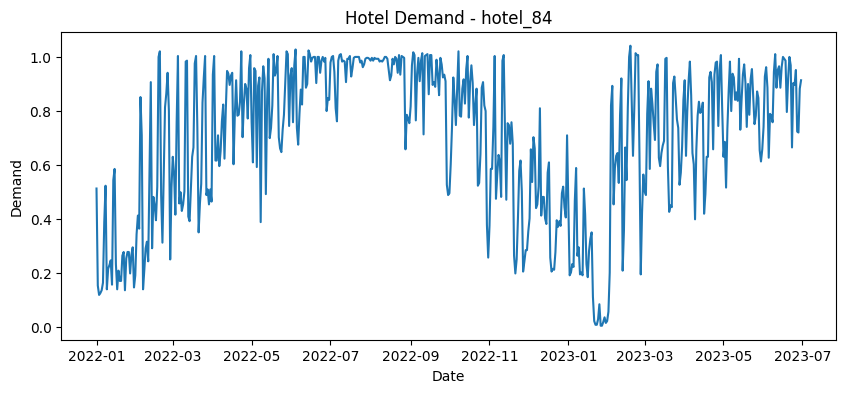

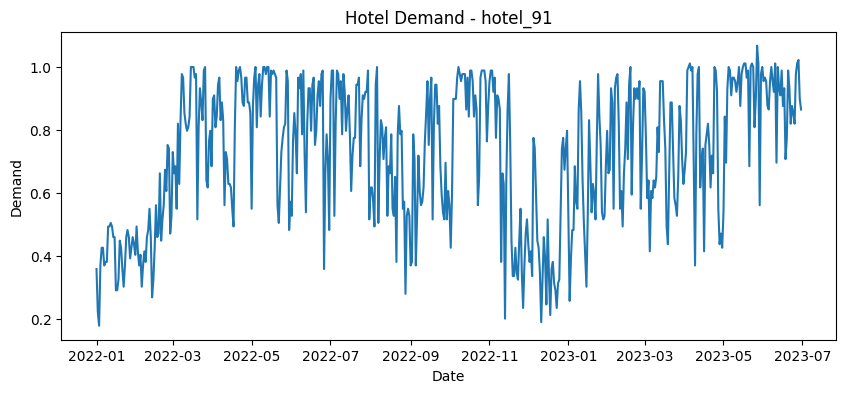

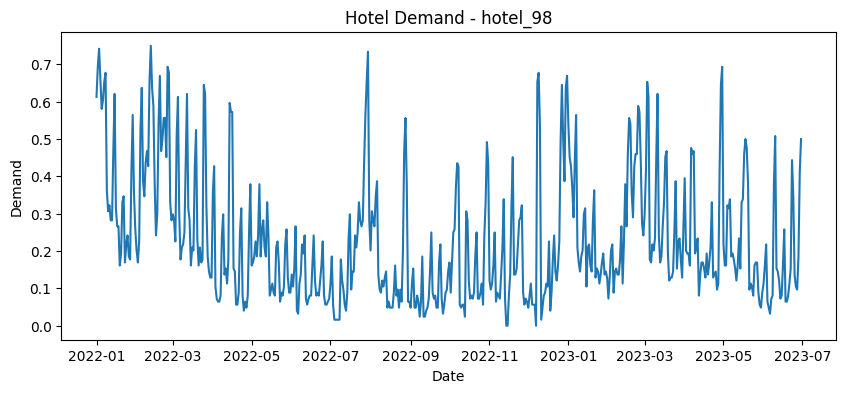

In [10]:
for hotel in df["unique_id"].unique():
  temp = df[df["unique_id"] == hotel]

  plt.figure(figsize=(10,4))
  plt.plot(temp["ds"], temp["y"])
  plt.title(f"Hotel Demand - {hotel}")
  plt.xlabel("Date")
  plt.ylabel("Demand")
  plt.show()

### Time Series Visualization and Interpretation

The hotel demand shows a wide range of patterns across properties.

Many hotels display clear weekly seasonality, with demand rising and falling in a consistent short-term cycle. This is expected because hotel occupancy is often different between weekdays and weekends.

At the same time, there is significant variation across hotels. Some properties operate close to full capacity most of the time while others are much more volatile or show clear upward trends. This could mean that different hotels behave very differently, making it unlikely that one model will work best for all of them.

Several hotels also experience sharp changes in demand over time, including periods of very low demand followed by some recovery. These shifts indicate that the data is not stable and that models need to handle any of the changing patterns.

In addition, many series contain sudden spikes and drops, which adds noise and makes forecasting more challenging for simple models.

Finally, the target variable is bounded between 0 and 1, representing occupancy. Some hotels frequently reach values near 1, meaning capacity limits that prevent demand from increasing further.



### Implications for Model Selection

Because of these patterns, it makes sense to compare a range of models:

- Simple baselines (Naive, Seasonal Naive)
- Statistical models (AutoETS, AutoARIMA)
- Machine learning (LightGBM with lag features)
- Neural models (NBEATS, NHITS)

Given the differences across hotels and shifting demand patterns, using cross-validation to compare models is best for selecting the best approach.

## **Step 7: Cross-Validation setup**

In [11]:
h = 28
n_windows = 5
step_size = 28
season_length = 7

### Cross-validation setup

We use 5-fold time-series cross-validation with a:

- Forecast horizon of 28 days
- Step size: 28 days
- Season length: 7 days (weekly seasonality)

This makes sure that evaluation shows real forecasting conditions, where future values are predicted using only past data.

## **Step 8: StatsForecast Models**

Define the models

In [12]:
models = [
    Naive(alias = "Naive"),
    SeasonalNaive(season_length = 7, alias = "SeasonalNaive"),
    AutoETS(season_length = 7, alias = "AutoETS"),
    AutoARIMA(season_length = 7, alias = "AutoARIMA")
]

Initialize StatsForecast

In [13]:
sf = StatsForecast(
    models = models,
    freq = "D",
    n_jobs = -1
)

Run the Cross-validation

In [14]:
cv_sf = sf.cross_validation(
    df = df,
    h = h,
    n_windows = n_windows,
    step_size = step_size
)

cv_sf.head() # takes roughly 10 minutes to run

,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoETS,AutoARIMA
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.691358,0.987654,0.798058,0.777053
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.691358,0.604938,0.592257,0.612408
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.691358,0.913580,0.611757,0.798756
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.691358,0.716049,0.625062,0.785560
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.691358,0.666667,0.616607,0.793339


### Baseline and Statistical Models

I start by implementing several baseline and statistical models using the StatsForecast library.

- Naive: predicts the next value using the most recent observation  
- Seasonal Naive: uses the value from the same day last week (lag 7)  
- AutoETS: models level, trend, and seasonality automatically  
- AutoARIMA: captures autocorrelation and differencing patterns in the data  

These models provide a strong baseline and help establish how much improvement we get from more of the advanced approaches like machine learning and the neural networks.

## **Step 9: Evaluate the Model Performance**

In [15]:
metrics = [bias, mae, rmse, mape]

eval_sf = evaluate(
    df = cv_sf,
    metrics = metrics,
    models = ["Naive", "SeasonalNaive", "AutoETS", "AutoARIMA"]
)

eval_sf.head()

,unique_id,cutoff,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA
0,hotel_77,2022-07-23,bias,-0.000439,-0.000439,0.007557,0.001581
1,hotel_77,2022-08-20,bias,-0.001130,-0.001130,0.001800,-0.001463
2,hotel_77,2022-09-17,bias,-0.000188,-0.001444,-0.004241,-0.001361
3,hotel_77,2022-10-15,bias,0.009164,0.003138,0.008733,0.009700
4,hotel_77,2022-11-22,bias,0.000000,0.000000,-0.000047,0.000569


In [16]:
eval_sf_avg = (
    eval_sf
    .groupby(["unique_id", "metric"])
    .mean(numeric_only = True)
    .reset_index()
)

eval_sf_avg.head()

,unique_id,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA
0,hotel_0,bias,0.082011,0.029806,-0.007384,0.052847
1,hotel_0,mae,0.194709,0.214286,0.184314,0.164152
2,hotel_0,mape,0.341090,0.354191,0.297296,0.283008
3,hotel_0,rmse,0.238226,0.252785,0.216098,0.195586
4,hotel_105,bias,0.053190,-0.073854,-0.062427,-0.060943


In [17]:
eval_sf_avg.to_csv("cv_results_statsforecast.csv", index=False)

### Example Model Interpretation (Hotel-Level)

For hotel_0, AutoARIMA performs best overall, having the lowest MAE, RMSE, and MAPE.

AutoETS has the lowest bias, meaning its predictions are more balanced between over- and under-forecasting, but it's not as accurate overall.

The Naive model performs worst. The Seasonal Naive model also underperforms, even though the data shows weekly patterns.

This suggests that while seasonality is present, it is not enough on its own. More flexible models like ARIMA are better able to better capture more of the underlying structure of the data.

## **Step 10: Model Wins**

In [18]:
# convert to long format
long_eval = eval_sf_avg.melt(
    id_vars = ["unique_id", "metric"],
    var_name = "model",
    value_name = "value"
)

# find the winning model per hotel and metric
wins = (
    long_eval
    .dropna()
    .sort_values(["unique_id", "metric", "value"])
    .groupby(["unique_id", "metric"])
    .first()
    .reset_index()
)

# count how many times each model wins
win_counts = (
    wins
    .groupby(["metric", "model"])
    .size()
    .reset_index(name = "wins")
    .sort_values(["metric", "wins"], ascending = [True, False])

)

win_counts

,metric,model,wins
0,bias,AutoARIMA,7
1,bias,AutoETS,6
3,bias,SeasonalNaive,5
2,bias,Naive,1
4,mae,AutoARIMA,8
5,mae,AutoETS,5
6,mae,Naive,5
7,mae,SeasonalNaive,1
8,mape,AutoARIMA,8
9,mape,AutoETS,5


In [19]:
win_counts.to_csv("model_wins_statsforecast.csv", index=False)

### Model Comparison Results

The model comparison shows the differences across the approaches.

- AutoARIMA performs best overall, with the most wins across MAE, MAPE, and RMSE.
- AutoETS is consistently strong, usually just behind AutoARIMA.
- The Naive model still wins in a few cases, suggesting that some hotel series are highly volatile or behave randomly.
- The Seasonal Naive model performs poorly, even though weekly patterns are present in the data.

### Key Insight

While weekly seasonality exists, it is not enough on its own to create any accurate forecasts. Models also need to capture the trend, volatility, and structural changes.

This is why we need more flexible models like AutoARIMA and AutoETS.

### Conclusion

No single model works best for every hotel, but AutoARIMA provides the strongest overall performance and serves as a reliable baseline for this data.



## **Step 11: Set up LightGBM model**

In [20]:
ml_models = {
    "LightGBM": LGBMRegressor(
        random_state = 100,
        n_estimators = 500,
        learning_rate = 0.05,
        num_leaves = 31
    )
}

mlf = MLForecast(
    models = ml_models,
    freq = "D",
    lags = [1, 7, 14, 28],
    date_features = ["dayofweek", "month"]
)

### Machine Learning Model: LightGBM

I use LightGBM through MLForecast as my machine learning model.

The selected lags are:

- Lag 1: yesterday’s demand  
- Lag 7: same day last week  
- Lag 14: two weeks ago  
- Lag 28: four weeks ago  

These lags reflect patterns seen in the data, especially short-term dependence and weekly seasonality.

I also include calendar features such as day of week and month to help capture recurring demand patterns over time.

## **Step 12: Run MLForecast cross-validation**

In [21]:
# Create a complete daily date range for each hotel
df_ml = (
    df
    .set_index("ds")
    .groupby("unique_id")
    .apply(lambda x: x.asfreq("D"))
    .drop(columns="unique_id")
    .reset_index()
)

# Fill missing demand values with 0
df_ml["y"] = df_ml["y"].fillna(0)

# Sort again
df_ml = df_ml.sort_values(["unique_id", "ds"]).reset_index(drop=True)

df_ml.head()

/tmp/ipykernel_113955/3174469136.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.asfreq("D"))


,unique_id,ds,y
0,hotel_0,2022-01-01,0.975309
1,hotel_0,2022-01-02,0.493827
2,hotel_0,2022-01-03,0.456790
3,hotel_0,2022-01-04,0.592593
4,hotel_0,2022-01-05,0.530864


In [22]:
cv_lgbm = mlf.cross_validation(
    df = df_ml,
    h = h,
    n_windows = n_windows,
    step_size = step_size,
)

cv_lgbm.head()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000536 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1040
[LightGBM] [Info] Number of data points in the train set: 6996, number of used features: 6
[LightGBM] [Info] Start training from score 0.677818
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000498 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1040
[LightGBM] [Info] Number of data points in the train set: 7528, number of used features: 6
[LightGBM] [Info] Start training from score 0.676598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000876 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1040
[LightGBM] [Info] Number of data points in the train set: 8060, number of used features: 6
[LightGBM] [Info] Start training 

,unique_id,ds,cutoff,y,LightGBM
0,hotel_0,2023-02-11,2023-02-10,0.827160,0.844721
1,hotel_0,2023-02-12,2023-02-10,0.518519,0.690973
2,hotel_0,2023-02-13,2023-02-10,0.629630,0.781520
3,hotel_0,2023-02-14,2023-02-10,0.629630,0.782371
4,hotel_0,2023-02-15,2023-02-10,0.888889,0.766775


### Handling Missing Time Steps for MLForecast

MLForecast requires each time series to have consistent timestamps. One of the hotel series had missing daily dates, so the data was resampled to ensure a complete daily timeline for each hotel.

Missing values were filled with 0 so that lag features could be calculated consistently across all series.

In [23]:
eval_lgbm = evaluate(
    df = cv_lgbm,
    metrics = metrics,
    models = ["LightGBM"]
)

eval_lgbm_avg = (
    eval_lgbm
    .groupby(["unique_id", "metric"])
    .mean(numeric_only = True)
    .reset_index()
)

eval_lgbm_avg.head()

,unique_id,metric,LightGBM
0,hotel_0,bias,0.024600
1,hotel_0,mae,0.140419
2,hotel_0,mape,0.240907
3,hotel_0,rmse,0.170451
4,hotel_105,bias,-0.057967


In [24]:
eval_lgbm_avg.to_csv("cv_results_lightgbm.csv", index=False)

### Combine with StatsForecast results

In [25]:
eval_combined = eval_sf_avg.merge(
    eval_lgbm_avg,
    on = ["unique_id", "metric"],
    how = "left"
)

eval_combined.head()

,unique_id,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA,LightGBM
0,hotel_0,bias,0.082011,0.029806,-0.007384,0.052847,0.024600
1,hotel_0,mae,0.194709,0.214286,0.184314,0.164152,0.140419
2,hotel_0,mape,0.341090,0.354191,0.297296,0.283008,0.240907
3,hotel_0,rmse,0.238226,0.252785,0.216098,0.195586,0.170451
4,hotel_105,bias,0.053190,-0.073854,-0.062427,-0.060943,-0.057967


In [26]:
eval_combined.to_csv("cv_results_statsforecast_lightgbm.csv", index=False)

### Recount Model wins including LightGBM

In [27]:
long_eval_combined = eval_combined.melt(
    id_vars = ["unique_id", "metric"],
    var_name = "model",
    value_name = "value"
)

wins_combined = (
    long_eval_combined
    .dropna()
    .sort_values(["unique_id", "metric", "value"])
    .groupby(["unique_id", "metric"])
    .first()
    .reset_index()
)

win_counts_combined = (
    wins_combined
    .groupby(["metric", "model"])
    .size()
    .reset_index(name="wins")
    .sort_values(["metric", "wins"], ascending=[True, False])
)

win_counts_combined

,metric,model,wins
0,bias,AutoARIMA,5
1,bias,AutoETS,5
2,bias,LightGBM,4
4,bias,SeasonalNaive,4
3,bias,Naive,1
7,mae,LightGBM,7
8,mae,Naive,5
5,mae,AutoARIMA,4
6,mae,AutoETS,2
9,mae,SeasonalNaive,1


### Machine Learning vs Statistical Models

Adding the LightGBM model changes the results a lot.

### Key Findings

- LightGBM performs best overall, with the most wins for MAE and MAPE.
- AutoARIMA is still good, especially for RMSE, where it handles larger errors better.
- AutoETS remains consistent, but is mostly outperformed by LightGBM and AutoARIMA.
- The Naive model still wins occasionally, meaning some series are noisy or hard to predict.
- The Seasonal Naive model performs poorly, even though weekly patterns are present.

### Key Insight

LightGBM performs well because it uses lag features to capture patterns in the data, including short-term dependencies and nonlinear relationships.

While statistical models capture trend and seasonality, machine learning models are better at adapting to more complex behavior in the data.

### Conclusion

Overall, LightGBM provides the best accuracy, while AutoARIMA is a good alternative, particularly if we want to minimize large errors.

This shows the value of comparing different model types when working with real-world time series data.

## **Step 13: Define neural models**

In [28]:
nf_models = [
    AutoNBEATS(h=h),
    AutoNHITS(h=h)
]

## **Step 14: Initialize NeuralForecast**

Use the cleaned daily data since it has the gaps handled

In [29]:
nf_models = [
    AutoNBEATS(
        h=h,
        config={"max_steps": 100, "input_size": 56} # input_size moved inside config
    ),
    AutoNHITS(
        h=h,
        config={"max_steps": 100, "input_size": 56} # input_size moved inside config
    )
]

nf = NeuralForecast(
    models=nf_models,
    freq="D"
)

## **Step 15: Run neural cross-validation**

In [30]:
cv_nf = nf.cross_validation(
    df=df_ml,
    n_windows=1,
    step_size=step_size
)
# this takes roughly 20 minutes to run
cv_nf.head()

2026-04-29 23:31:59,161	INFO worker.py:2012 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2026-04-29 23:32:03,083	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.


+--------------------------------------------------------------------+
| Configuration for experiment     _train_tune_2026-04-29_23-31-46   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        FIFOScheduler                     |
| Number of trials                 10                                |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/_train_tune_2026-04-29_23-31-46
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-04-29_23-31-46_427978_113955/artifacts/2026-04-29_23-32-03/_train_tune_2026-04-29_23-31-46/driver_artifacts`


(_train_tune pid=117950) /usr/local/lib/python3.12/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=117950) Seed set to 1
(_train_tune pid=117950) GPU available: False, used: False
(_train_tune pid=117950) TPU available: False, using: 0 TPU cores
(_train_tune pid=117950) 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
(_train_tune pid=117950) 2026-04-29 23:32:19.486788: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
(_train_tune pid=117950) 2026-04-29 23:32:19.628522: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimi

(_train_tune pid=117950) ┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
(_train_tune pid=117950) ┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
(_train_tune pid=117950) ┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
(_train_tune pid=117950) │ 0 │ loss         │ MAE           │      0 │ train │     0 │
(_train_tune pid=117950) │ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
(_train_tune pid=117950) │ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
(_train_tune pid=117950) │ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
(_train_tune pid=117950) └───┴──────────────┴───────────────┴────────┴───────┴───────┘
(_train_tune pid=117950) Trainable params: 2.6 M                                                         
(_train_tune pid=117950) Non-trainable params: 4.8 K                                                     
(_train_tune pid=117950) Total params: 2.6 M                                                

(_train_tune pid=117950) /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

,unique_id,ds,cutoff,AutoNBEATS,AutoNHITS,y
0,hotel_0,2023-06-03,2023-06-02,0.802002,0.751688,0.864198
1,hotel_0,2023-06-04,2023-06-02,0.511268,0.565478,0.506173
2,hotel_0,2023-06-05,2023-06-02,0.471604,0.500612,0.740741
3,hotel_0,2023-06-06,2023-06-02,0.595011,0.560733,0.753086
4,hotel_0,2023-06-07,2023-06-02,0.588912,0.620888,0.753086


## Neural Model Cross-Validation Adjustment

Due to the computational cost of neural forecasting models, we reduce the number of cross-validation windows from 5 to 1 for these models.

This allows us to maintain a fair comparison while ensuring reasonable runtime, which is an important consideration in real-world forecasting applications.

## **Step 16: Evaluate neural models**

In [31]:
neural_model_names = [
    col for col in cv_nf.columns
    if col not in ["unique_id", "ds", "cutoff", "y"]
]

neural_model_names

['AutoNBEATS', 'AutoNHITS']

In [32]:
eval_nf = evaluate(
    df = cv_nf,
    metrics = metrics,
    models = neural_model_names
)

eval_nf_avg = (
    eval_nf
    .groupby(["unique_id", "metric"])
    .mean(numeric_only = True)
    .reset_index()
)

eval_nf_avg.head()

,unique_id,metric,AutoNBEATS,AutoNHITS
0,hotel_0,bias,-0.107218,-0.092473
1,hotel_0,mae,0.108217,0.110393
2,hotel_0,mape,0.143678,0.145425
3,hotel_0,rmse,0.133503,0.130500
4,hotel_105,bias,-0.067630,-0.072846


In [33]:
eval_nf_avg.to_csv("cv_results_neural.csv", index=False)

## **Step 17: Add neural models to combined results**

In [34]:
eval_all = eval_combined.merge(
    eval_nf_avg,
    on = ["unique_id", "metric"],
    how = "left"
)

eval_all.head()

,unique_id,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA,LightGBM,AutoNBEATS,AutoNHITS
0,hotel_0,bias,0.082011,0.029806,-0.007384,0.052847,0.024600,-0.107218,-0.092473
1,hotel_0,mae,0.194709,0.214286,0.184314,0.164152,0.140419,0.108217,0.110393
2,hotel_0,mape,0.341090,0.354191,0.297296,0.283008,0.240907,0.143678,0.145425
3,hotel_0,rmse,0.238226,0.252785,0.216098,0.195586,0.170451,0.133503,0.130500
4,hotel_105,bias,0.053190,-0.073854,-0.062427,-0.060943,-0.057967,-0.067630,-0.072846


In [35]:
eval_all.to_csv("cv_results_all_models.csv", index=False)

## Step 18: Recount all the model wins

In [36]:
long_eval_all = eval_all.melt(
    id_vars = ["unique_id", "metric"],
    var_name = "model",
    value_name = "value"
)

wins_all = (
    long_eval_all
    .dropna()
    .sort_values(["unique_id", "metric", "value"])
    .groupby(["unique_id", "metric"])
    .first()
    .reset_index()
)

win_counts_all = (
    wins_all
    .groupby(["metric", "model"])
    .size()
    .reset_index(name="wins")
    .sort_values(["metric", "wins"], ascending=[True, False])
)

win_counts_all

,metric,model,wins
2,bias,AutoNBEATS,7
3,bias,AutoNHITS,4
0,bias,AutoARIMA,3
4,bias,LightGBM,2
1,bias,AutoETS,1
5,bias,Naive,1
6,bias,SeasonalNaive,1
8,mae,AutoNBEATS,8
9,mae,AutoNHITS,5
11,mae,Naive,4


In [37]:
win_counts_all.to_csv("model_wins_all_models.csv", index=False)

## **Final Model Comparison**

Including neural models changes the results a lot.

### Key Findings

- AutoNBEATS performs best overall, with the most wins for MAE and MAPE.
- AutoNHITS performs best for RMSE, meaning it handles large errors more effectively.
- Both neural models outperform statistical models (AutoARIMA, AutoETS) and the machine learning model (LightGBM).

- LightGBM, which performed well earlier, is no longer good at all, and the statistical models also fall behind once neural models are included.

### Key Insight

The strong performance of neural models shows that hotel demand is complex and not driven by simple patterns.

Neural models are better at capturing:
- nonlinear relationships  
- sudden changes in demand  
- more complex time-based patterns  

This gives them an advantage over both statistical and machine learning models.

### Model Tradeoffs

- AutoNBEATS performs best on average (MAE, MAPE)
- AutoNHITS performs best when large errors matter most (RMSE)

### Conclusion

Neural models provide the best overall performance for this dataset. However, they come at a higher computational cost.

This shows a tradeoff. More accurate models require more time and resources, so model choice needs to balance both performance and practicality.

## Step 19: Final Forecasts

In [38]:
nbeats_config = {"max_steps": 100, "input_size": 56}

nf_final = NeuralForecast(
    models=[
        AutoNBEATS(
            h=h,
            config=nbeats_config,
            num_samples=1
        )
    ],
    freq="D"
)

nf_final.fit(df_ml)

final_nf = nf_final.predict()

final_nf.head()

+--------------------------------------------------------------------+
| Configuration for experiment     _train_tune_2026-04-29_23-51-53   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        FIFOScheduler                     |
| Number of trials                 1                                 |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/_train_tune_2026-04-29_23-51-53
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-04-29_23-31-46_427978_113955/artifacts/2026-04-29_23-51-53/_train_tune_2026-04-29_23-51-53/driver_artifacts`


(_train_tune pid=123746) /usr/local/lib/python3.12/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=123746) Seed set to 1
(_train_tune pid=123746) GPU available: False, used: False
(_train_tune pid=123746) TPU available: False, using: 0 TPU cores
(_train_tune pid=123746) 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
(_train_tune pid=123746) 2026-04-29 23:52:09.170557: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
(_train_tune pid=123746) 2026-04-29 23:52:09.254672: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimi

(_train_tune pid=123746) ┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
(_train_tune pid=123746) ┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
(_train_tune pid=123746) ┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
(_train_tune pid=123746) │ 0 │ loss         │ MAE           │      0 │ train │     0 │
(_train_tune pid=123746) │ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
(_train_tune pid=123746) │ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
(_train_tune pid=123746) │ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
(_train_tune pid=123746) └───┴──────────────┴───────────────┴────────┴───────┴───────┘
(_train_tune pid=123746) Trainable params: 2.6 M                                                         
(_train_tune pid=123746) Non-trainable params: 4.8 K                                                     
(_train_tune pid=123746) Total params: 2.6 M                                                

(_train_tune pid=123746) /usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
2026-04-29 23:52:45,562	INFO tune.py:1001 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/_train_tune_2026-04-29_23-51-53' in 0.0108s.
INFO:lightning_fabric.utilities.seed:Seed set to 1


(_train_tune pid=123746) `Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


,unique_id,ds,AutoNBEATS
0,hotel_0,2023-07-01,0.917476
1,hotel_0,2023-07-02,0.649643
2,hotel_0,2023-07-03,0.606653
3,hotel_0,2023-07-04,0.735730
4,hotel_0,2023-07-05,0.741401


For the final forecast, AutoNBEATS was selected because it achieved the strongest performance on MAE and MAPE during cross-validation.

In [39]:
final_nf.to_csv("final_forecasts_autonbeats.csv", index=False)

### Plot forecasts

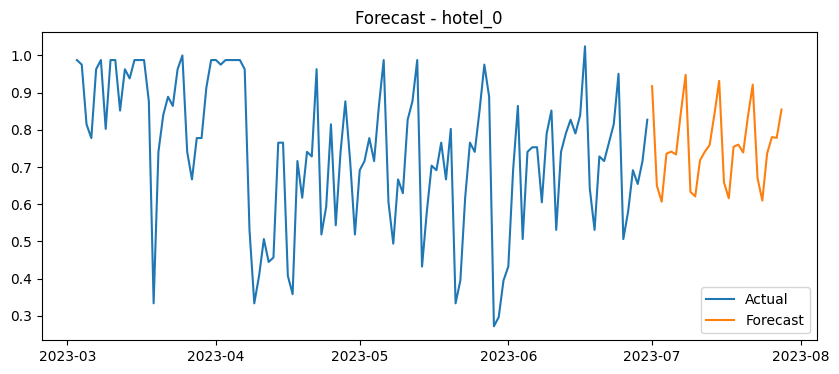

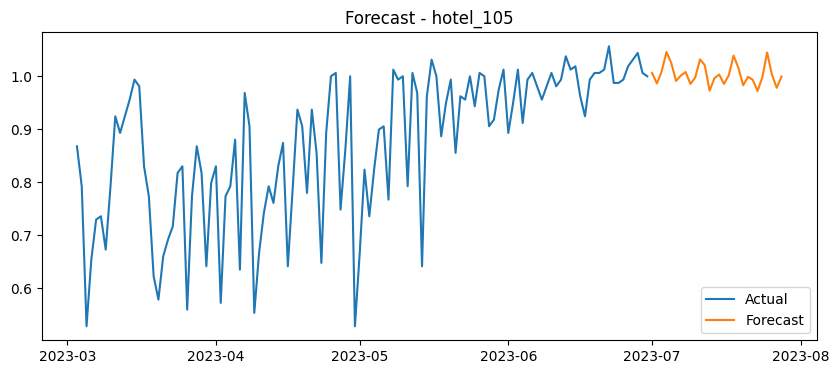

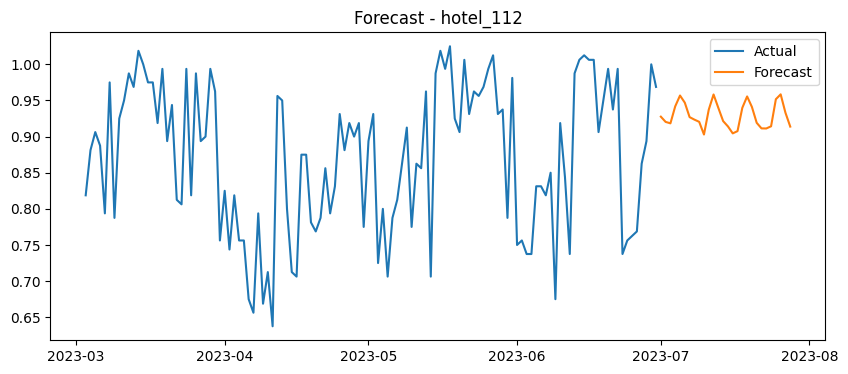

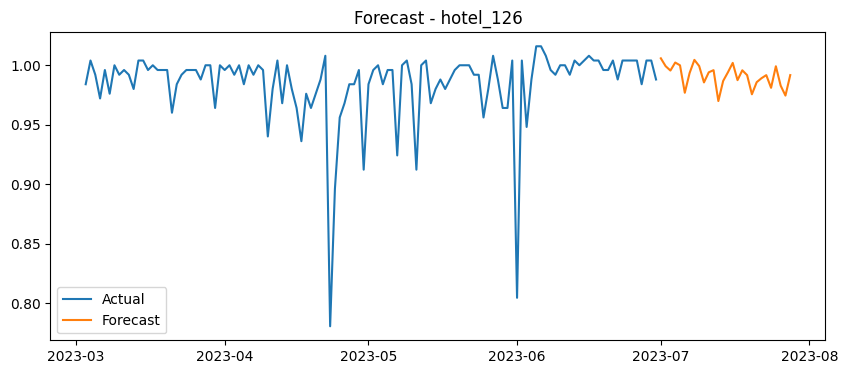

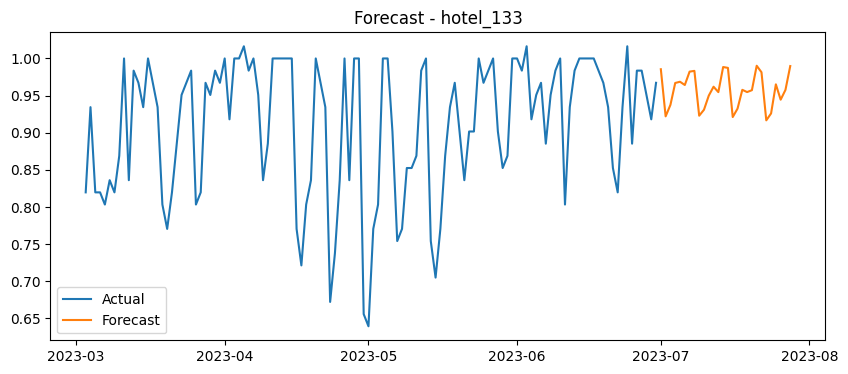

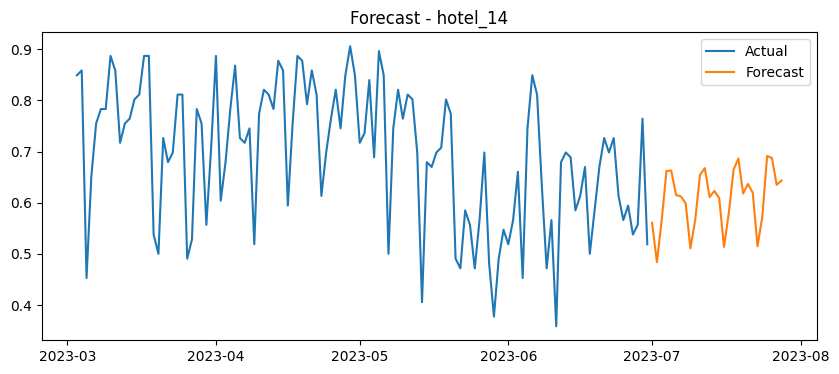

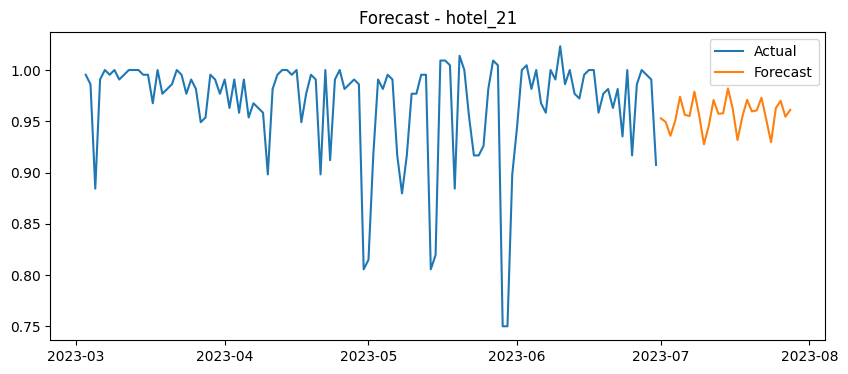

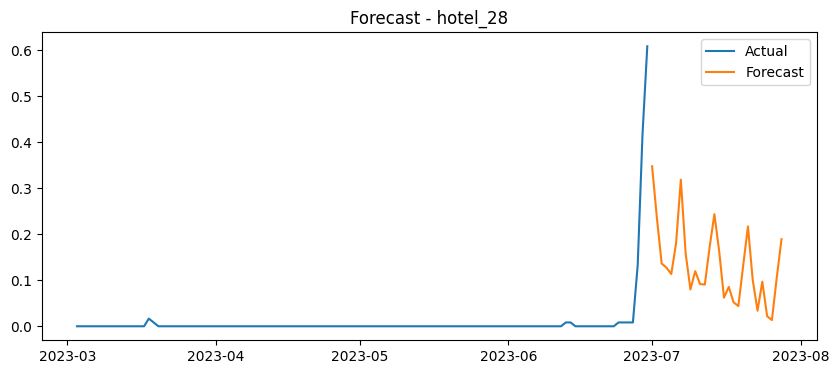

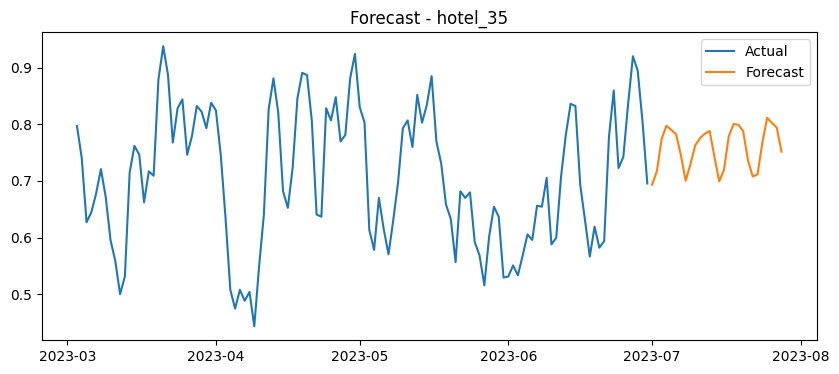

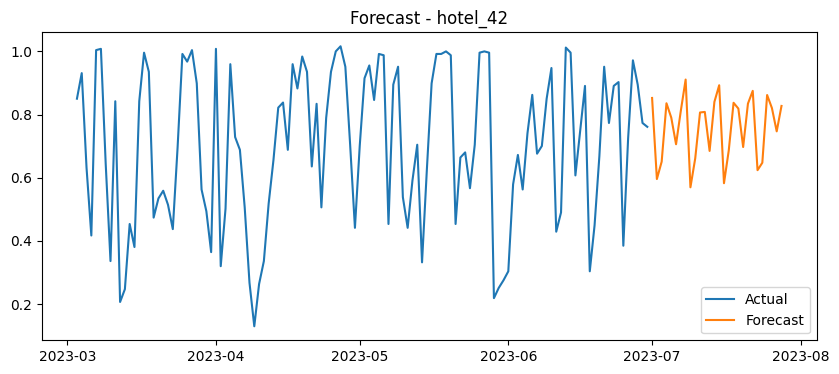

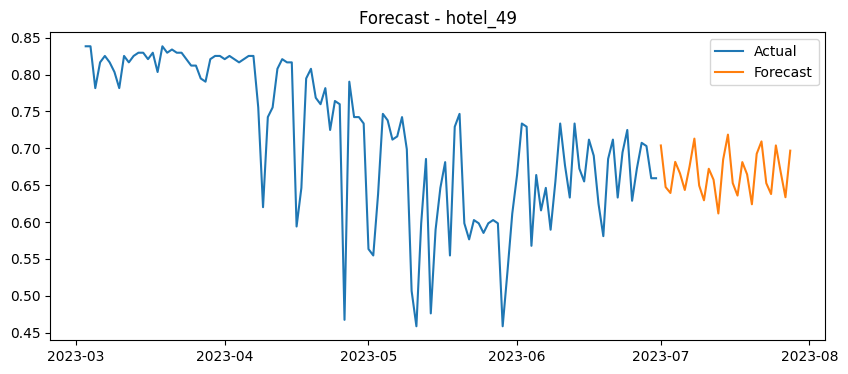

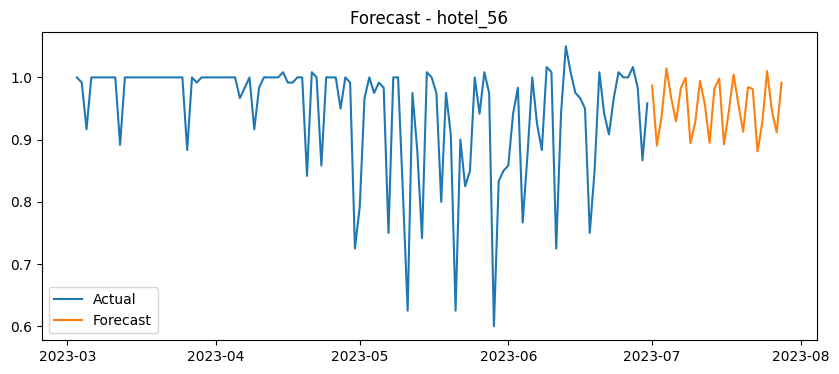

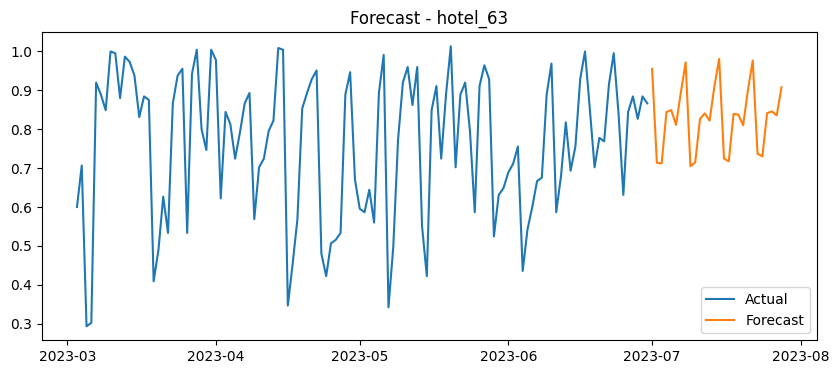

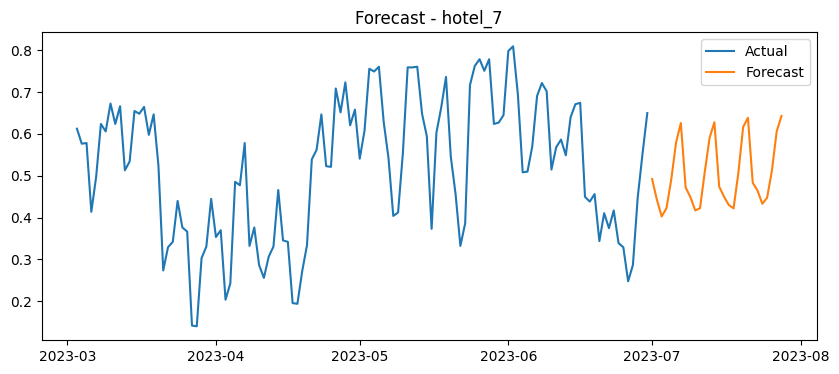

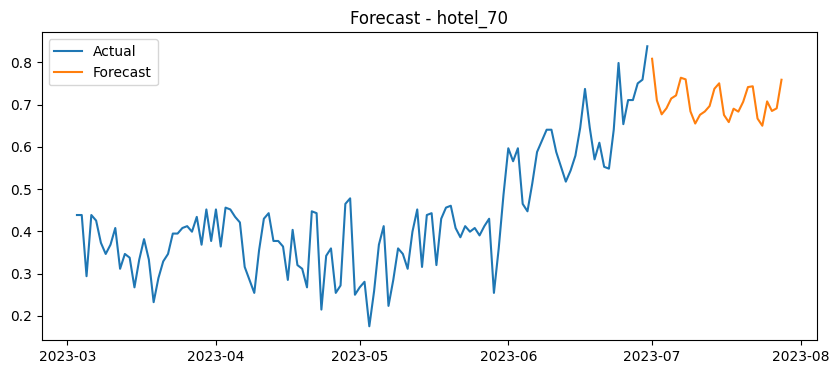

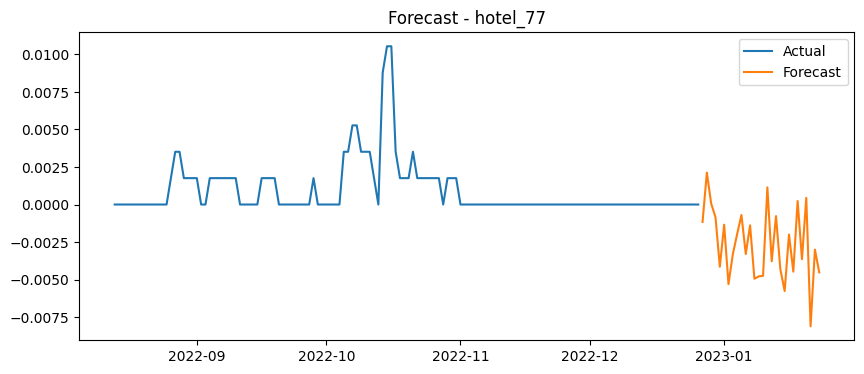

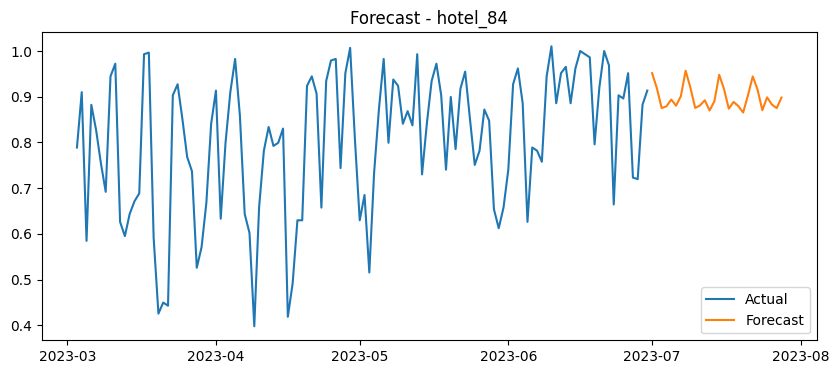

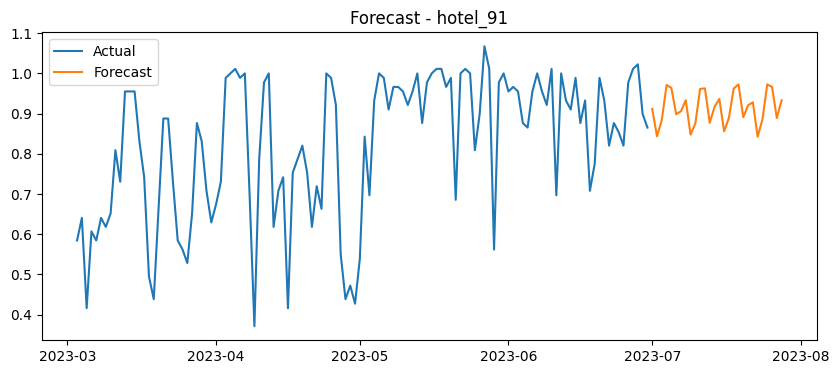

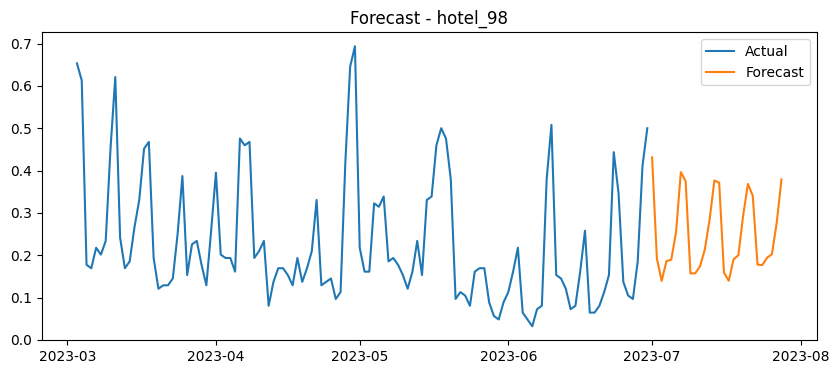

In [42]:
import os
import matplotlib.pyplot as plt

# Make sure folder exists
os.makedirs("plots", exist_ok=True)

# Loop through ALL hotels
for hotel in df["unique_id"].unique():

    actuals = df[df["unique_id"] == hotel].tail(120)
    forecast = final_nf[final_nf["unique_id"] == hotel]

    # Skip if forecast missing
    if forecast.empty:
        continue

    plt.figure(figsize=(10,4))

    plt.plot(actuals["ds"], actuals["y"], label="Actual")
    plt.plot(forecast["ds"], forecast["AutoNBEATS"], label="Forecast")

    plt.title(f"Forecast - {hotel}")
    plt.legend()

    plt.savefig(f"plots/{hotel}_forecast.png")

    plt.show()

    plt.close()

## Final Takeaways

- Neural models performed best overall
- LightGBM performed well but was surpassed by neural models
- Statistical models provided strong baselines but were less flexible
- Model choice depends on accuracy vs computational cost

Download the plots

In [44]:
#import shutil
#from google.colab import files

# shutil.make_archive("forecast_plots", "zip", "plots")

# files.download("forecast_plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>